# ML and DL

## Dependencies

In [1]:
import os
import random
import sys
import warnings

import dill
import numpy as np
import pandas as pd
import torch
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [2]:
warnings.filterwarnings("ignore")  # 忽略警告
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]  # 用来正常显示中文标签
plt.rcParams["axes.unicode_minus"] = False  # 用来正常显示负号

In [3]:
root_dir = "C:\\ML4GM"
outputs_dir = os.path.join(root_dir, "models")  # 输出路径
os.makedirs(outputs_dir, exist_ok=True)  # 创建数据目录

In [4]:
def save_pkl(filepath, data):
    # 保存模型
    with open(filepath, "wb") as fw:
        dill.dump(data, fw)
    print(f"[{filepath}] data saving...")

## Load and proc

In [5]:
# 加载完整合并数据（含 lapse_rate 和 elev_grad，与论文 Sec.2.3.1 一致）
data = pd.read_csv("C:\\ML4GM\\proc_data\\02_merge\\merged_data.csv")

# 删除 WW/RGI 元数据列（不参与建模）
_drop_meta = [
    'area', 'err_dhdt', 'dvoldt', 'err_dvoldt', 'dmdt', 'err_dmdt',
    'dmdtda', 'err_dmdtda', 'perc_area_meas', 'perc_area_res',
    'valid_obs', 'valid_obs_py', 'reg', 'join_key',
    'RGIId', 'BgnDate', 'EndDate', 'O1Region', 'O2Region',
    'Status', 'Connect', 'Form', 'TermType', 'Surging', 'Linkages', 'Name',
]

# 排除 d2m（露点温度）、u10/v10（风速分量），其余 ERA5 变量全部保留
_unused_era5 = ['d2m', 'u10', 'v10']
_drop_era5 = [f"{m}_{v}" for v in _unused_era5 for m in range(1, 13)]

_drop_all = [c for c in _drop_meta + _drop_era5 if c in data.columns]
data = data.drop(columns=_drop_all)

# 验证关键特征列存在
lr_features   = [f"{m}_lr"  for m in range(1, 13)]  # 月度气温递减率（downscaling 变量）
grad_features = ['elev_grad']                         # 冰川质心与ERA5格点高程差（downscaling 变量）
assert all(c in data.columns for c in lr_features + grad_features), \
    "缺少 lr/elev_grad 列，请先运行 readWW.ipynb 中的递减率计算步骤"

# 统计实际保留的 ERA5 月度变量
_all_era5 = ['t2m', 'tp', 'rsn', 'sde', 'sf', 'fal', 'slhf', 'ssr', 'str',
             'sshf', 'ssrd', 'strd', 'sp']
_era5_kept = [v for v in _all_era5 if f"1_{v}" in data.columns]
print(f"数据维度: {data.shape}")
print(f"保留的 ERA5 月度变量（{len(_era5_kept)} 个）: {_era5_kept}")
print(f"  → 月度气候特征: {len(_era5_kept)}×12 = {len(_era5_kept)*12} 列")
print(f"  → downscaling: lr×12 + elev_grad×1 = 13 列")
print(f"地形特征: {[c for c in data.columns if c in ['CenLon','CenLat','Area','Zmin','Zmax','Zmed','Slope','Aspect','Lmax']]}")
data

数据维度: (162020, 194)
保留的 ERA5 月度变量（12 个）: ['t2m', 'tp', 'rsn', 'sde', 'sf', 'fal', 'slhf', 'ssr', 'sshf', 'ssrd', 'strd', 'sp']
  → 月度气候特征: 12×12 = 144 列
  → downscaling: lr×12 + elev_grad×1 = 13 列
地形特征: ['CenLon', 'CenLat', 'Area', 'Zmin', 'Zmax', 'Zmed', 'Slope', 'Aspect', 'Lmax']


,rgiid,year,dhdt,GLIMSId,CenLon,CenLat,Area,Zmin,Zmax,Zmed,...,4_lr,5_lr,6_lr,7_lr,8_lr,9_lr,10_lr,11_lr,12_lr,elev_grad
0,RGI60-13.00062,2000,0.4247,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,-0.006761,-0.006329,-0.005641,-0.005117,-0.005463,-0.006048,-0.006668,-0.006656,-0.006366,227.4
1,RGI60-13.00062,2001,0.4973,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,-0.006738,-0.006471,-0.005699,-0.005118,-0.005366,-0.006206,-0.006697,-0.006542,-0.006457,227.4
2,RGI60-13.00062,2002,0.3004,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,-0.006696,-0.006475,-0.005937,-0.005319,-0.005180,-0.006222,-0.006801,-0.006748,-0.006450,227.4
3,RGI60-13.00062,2003,0.1291,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,-0.006621,-0.006654,-0.005919,-0.005355,-0.005297,-0.005860,-0.006823,-0.006653,-0.006484,227.4
4,RGI60-13.00062,2004,0.4655,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,-0.006584,-0.006437,-0.005949,-0.005439,-0.005473,-0.005857,-0.006630,-0.006675,-0.006395,227.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162015,RGI60-15.13117,2015,-0.9031,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,-0.006431,-0.006127,-0.005318,-0.004938,-0.004940,-0.005260,-0.006365,-0.006452,-0.006322,126.6
162016,RGI60-15.13117,2016,-0.7985,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,-0.006495,-0.006006,-0.005095,-0.004758,-0.004903,-0.005216,-0.005987,-0.006590,-0.006516,126.6
162017,RGI60-15.13117,2017,-0.7527,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,-0.006447,-0.006026,-0.005278,-0.004784,-0.004815,-0.005197,-0.005871,-0.006577,-0.006280,126.6
162018,RGI60-15.13117,2018,-0.6610,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,-0.006478,-0.006081,-0.005099,-0.004749,-0.004758,-0.005319,-0.006584,-0.006564,-0.006508,126.6


In [6]:
# 保留 data 含 rgiid/year 供后续按组划分；EDA 使用不含 ID 的 data_eda
data_eda = data.drop(columns=["rgiid", "year", "GLIMSId"], axis=1)
data_eda

,dhdt,CenLon,CenLat,Area,Zmin,Zmax,Zmed,Slope,Aspect,Lmax,...,4_lr,5_lr,6_lr,7_lr,8_lr,9_lr,10_lr,11_lr,12_lr,elev_grad
0,0.4247,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,-0.006761,-0.006329,-0.005641,-0.005117,-0.005463,-0.006048,-0.006668,-0.006656,-0.006366,227.4
1,0.4973,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,-0.006738,-0.006471,-0.005699,-0.005118,-0.005366,-0.006206,-0.006697,-0.006542,-0.006457,227.4
2,0.3004,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,-0.006696,-0.006475,-0.005937,-0.005319,-0.005180,-0.006222,-0.006801,-0.006748,-0.006450,227.4
3,0.1291,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,-0.006621,-0.006654,-0.005919,-0.005355,-0.005297,-0.005860,-0.006823,-0.006653,-0.006484,227.4
4,0.4655,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,-0.006584,-0.006437,-0.005949,-0.005439,-0.005473,-0.005857,-0.006630,-0.006675,-0.006395,227.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162015,-0.9031,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,-0.006431,-0.006127,-0.005318,-0.004938,-0.004940,-0.005260,-0.006365,-0.006452,-0.006322,126.6
162016,-0.7985,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,-0.006495,-0.006006,-0.005095,-0.004758,-0.004903,-0.005216,-0.005987,-0.006590,-0.006516,126.6
162017,-0.7527,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,-0.006447,-0.006026,-0.005278,-0.004784,-0.004815,-0.005197,-0.005871,-0.006577,-0.006280,126.6
162018,-0.6610,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,-0.006478,-0.006081,-0.005099,-0.004749,-0.004758,-0.005319,-0.006584,-0.006564,-0.006508,126.6


### 缺失值统计与处理

In [7]:
# 缺失值统计
missing_count = data.isnull().sum()
missing_pct = (data.isnull().sum() / len(data) * 100).round(2)
missing_df = pd.DataFrame({"缺失数": missing_count, "缺失占比%": missing_pct})
print("各列缺失值统计：")
print(missing_df[missing_df["缺失数"] > 0] if missing_count.sum() > 0 else "无缺失值，无需处理。")

if missing_count.sum() > 0:
    # 目标列 dhdt：删除目标为缺失的行
    data = data.dropna(subset=["dhdt"])
    # 特征列：按列用中位数填充
    data = data.fillna(data.median(numeric_only=True))
    print("已处理：目标缺失行已删除，特征缺失已用中位数填充。")

各列缺失值统计：
无缺失值，无需处理。


### Correlation

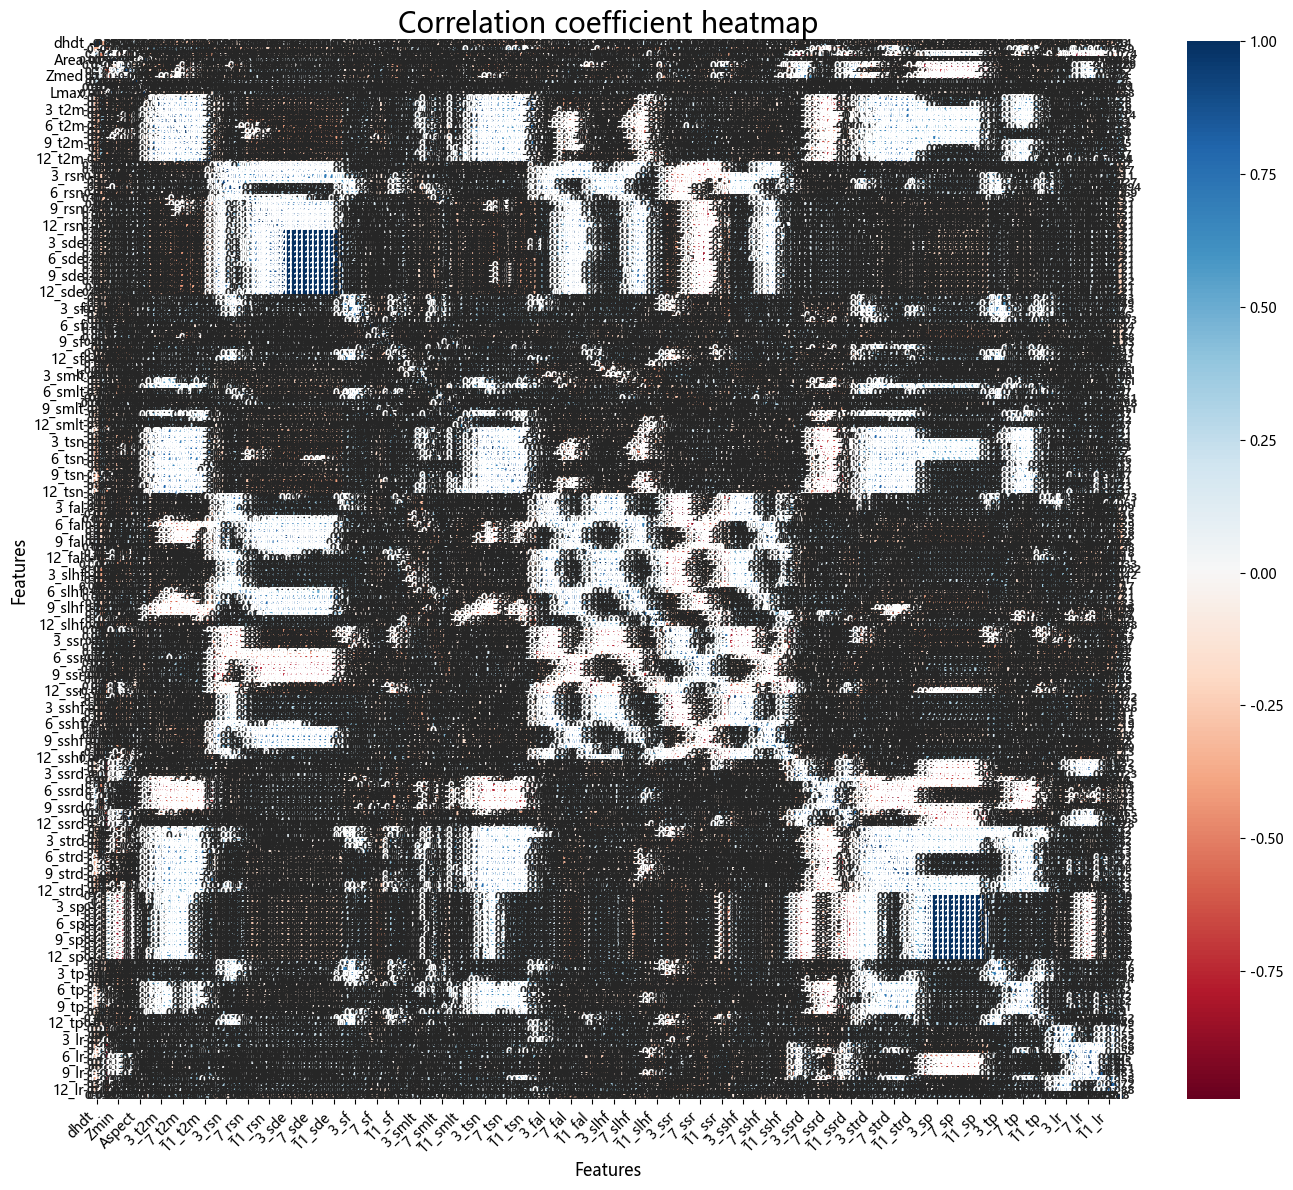

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 12), dpi=100)  # 定义画布
sns.heatmap(
    data_eda.corr(),
    annot=True,
    fmt=".2g",
    cmap="RdBu",
    annot_kws={"size": 8, "weight": "bold"},
    ax=ax,
)  # 绘制相关性图
ax.set_title("Correlation coefficient heatmap", fontsize=20)  # 标题
ax.set_xlabel("Features", fontsize=12)  # x轴标签
ax.set_ylabel("Features", fontsize=12)  # y轴标签
ax.tick_params(labelsize=10)  # 设置坐标轴轴刻度大小
plt.xticks(rotation=45, ha="right")
plt.tight_layout()  # 防重叠
plt.show()  # 显示图像
plt.close()  # 关闭图像

### 描述性统计

In [9]:
data_eda.describe()  # 描述性统计

,dhdt,CenLon,CenLat,Area,Zmin,Zmax,Zmed,Slope,Aspect,Lmax,...,4_lr,5_lr,6_lr,7_lr,8_lr,9_lr,10_lr,11_lr,12_lr,elev_grad
count,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,...,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000
mean,-0.257627,81.365969,35.166028,8.165258,4603.146649,5790.578571,5176.448093,19.727799,164.274904,5065.648685,...,-0.006705,-0.006402,-0.005805,-0.005337,-0.005396,-0.005921,-0.006543,-0.006640,-0.006589,405.781928
std,0.444020,7.583510,4.260026,25.345166,701.806128,692.965048,637.623030,6.110652,128.604322,3941.587662,...,0.000210,0.000398,0.000530,0.000480,0.000474,0.000522,0.000371,0.000250,0.000260,315.775024
min,-4.957200,68.124651,27.550145,2.000000,521.000000,1141.000000,610.000000,4.000000,0.000000,465.000000,...,-0.007446,-0.007487,-0.007140,-0.007076,-0.007049,-0.007116,-0.007252,-0.007297,-0.007301,-4207.900000
25%,-0.516800,75.758579,31.556688,2.634000,4056.000000,5421.000000,4802.000000,15.100000,39.000000,3103.000000,...,-0.006851,-0.006703,-0.006217,-0.005607,-0.005670,-0.006348,-0.006813,-0.006835,-0.006794,217.400000
50%,-0.221550,79.009959,35.660000,3.780000,4685.000000,5862.000000,5265.000000,19.100000,137.000000,4022.000000,...,-0.006717,-0.006497,-0.005821,-0.005206,-0.005255,-0.005913,-0.006663,-0.006655,-0.006590,375.600000
75%,0.028800,86.379000,37.925088,6.714000,5170.000000,6248.000000,5684.000000,23.700000,304.000000,5649.000000,...,-0.006585,-0.006122,-0.005297,-0.004942,-0.005008,-0.005418,-0.006340,-0.006461,-0.006411,568.400000
max,4.147000,103.098000,45.235130,1077.958000,7069.000000,8799.000000,7555.000000,45.300000,360.000000,76460.000000,...,-0.005920,-0.005394,-0.004896,-0.004697,-0.004716,-0.005032,-0.005305,-0.005632,-0.005330,2687.600000


### 目标与主要特征分布

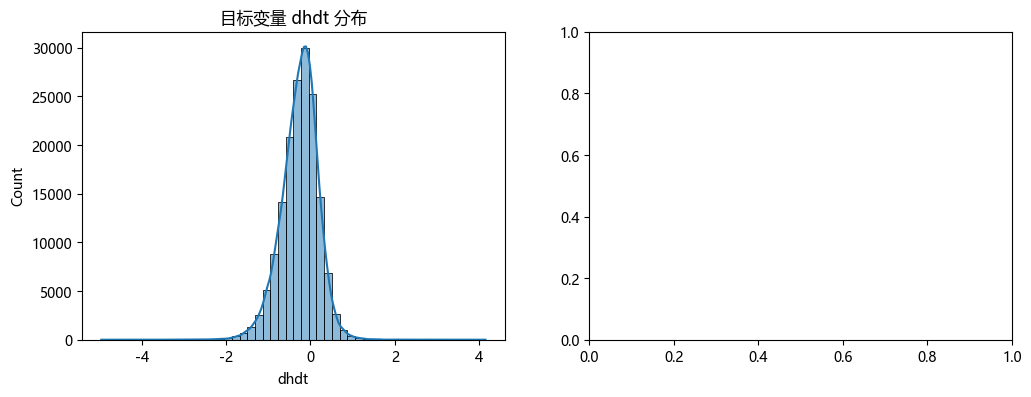

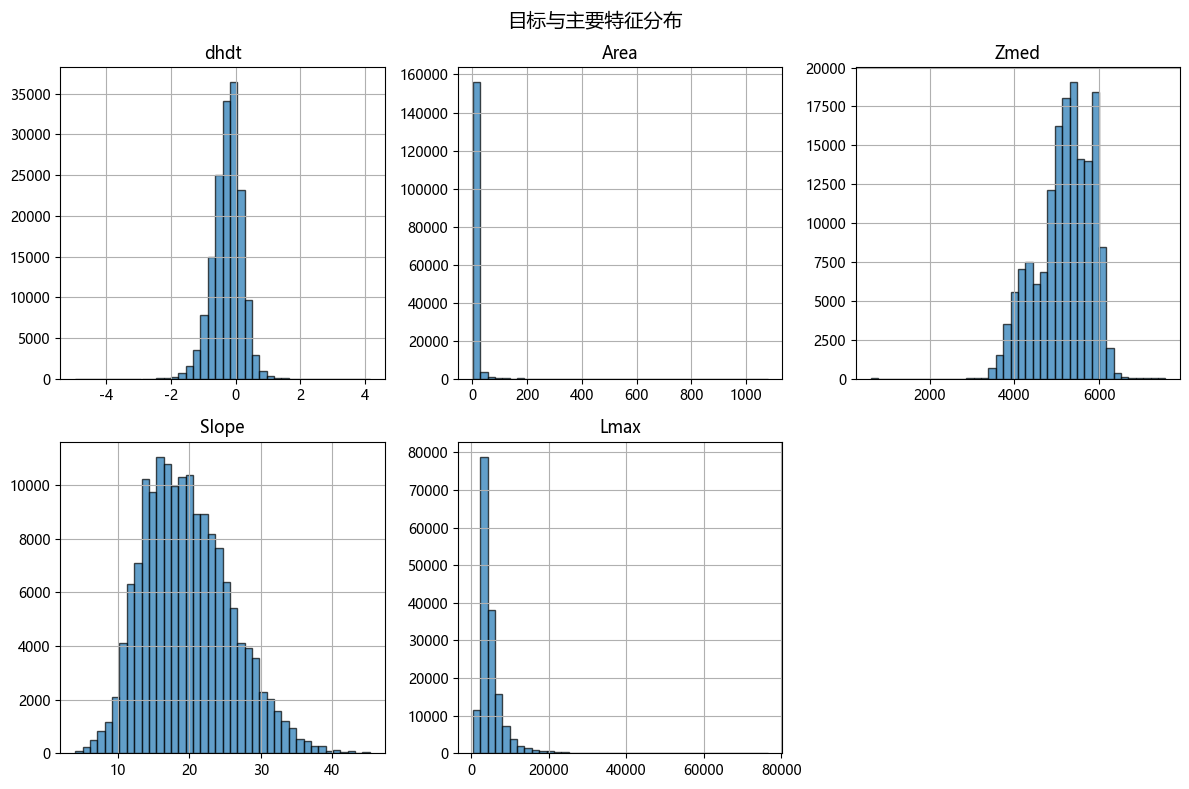

In [10]:
# 目标变量 dhdt 分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data_eda["dhdt"], kde=True, ax=axes[0], bins=50)
axes[0].set_title("目标变量 dhdt 分布")
axes[0].set_xlabel("dhdt")

# 主要特征分布（选取代表性列）
main_cols = ["dhdt", "Area", "Zmed", "Slope", "Lmax"]
data_eda[main_cols].hist(bins=40, figsize=(12, 8), layout=(2, 3), edgecolor="black", alpha=0.7)
plt.suptitle("目标与主要特征分布", fontsize=14)
plt.tight_layout()
plt.show()
plt.close()

### 异常值检查（可选）

dhdt: 异常值数量=3389, 占比=2.09%
Area: 异常值数量=17780, 占比=10.97%
Zmed: 异常值数量=320, 占比=0.2%
Lmax: 异常值数量=11840, 占比=7.31%


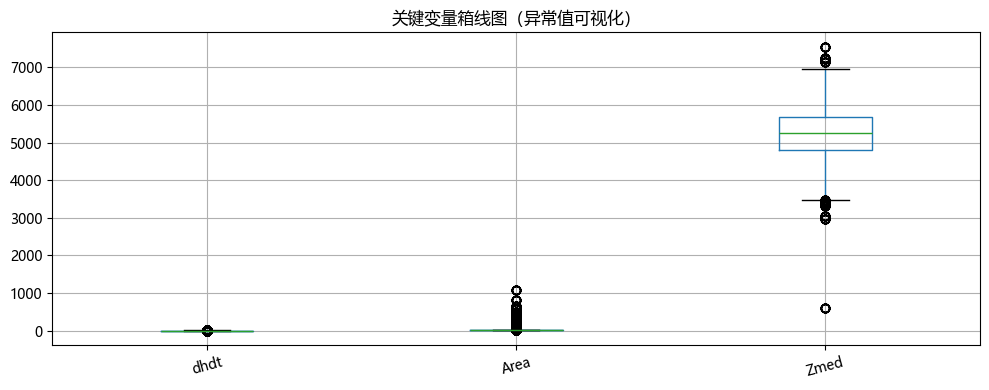

In [11]:
# IQR 异常值统计（仅检查，不删除）
check_cols = ["dhdt", "Area", "Zmed", "Lmax"]
for col in check_cols:
    Q1 = data_eda[col].quantile(0.25)
    Q3 = data_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((data_eda[col] < low) | (data_eda[col] > high)).sum()
    pct = (n_out / len(data_eda) * 100).round(2)
    print(f"{col}: 异常值数量={n_out}, 占比={pct}%")

# 关键变量箱线图
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
data_eda[["dhdt", "Area", "Zmed"]].boxplot(ax=ax)
ax.set_title("关键变量箱线图（异常值可视化）")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
plt.close()

### set x&y

In [12]:
feature_columns = data_eda.columns.tolist()[1:]  # 特征列
target_columns = data_eda.columns.tolist()[0]  # 目标列

X = data_eda[feature_columns].values  # 特征
y = data_eda[target_columns].values  # 目标

print(f"X shape: {X.shape}, y shape: {y.shape}")  # 打印维度

X shape: (162020, 190), y shape: (162020,)


In [13]:
# --- 保存预处理数据供 02-07 使用（仅保留全量数据，不含 holdout 划分）---
_data = {
    "feature_columns": feature_columns,
    "X_all":     X,
    "y_all":     y,
    "rgiid_all": data["rgiid"].values,
    "year_all":  data["year"].values,
}
save_pkl(os.path.join(outputs_dir, "preprocessed_data.pkl"), _data)
print("Preprocessed data saved to", os.path.join(outputs_dir, "preprocessed_data.pkl"))

[C:\ML4GM\models\preprocessed_data.pkl] data saving...
Preprocessed data saved to C:\ML4GM\models\preprocessed_data.pkl


In [14]:
print("pkl keys:", list(_data.keys()))
print(f"X_all: {_data['X_all'].shape}, y_all: {_data['y_all'].shape}")
print(f"Unique glaciers: {len(np.unique(_data['rgiid_all']))}, "
      f"years: {sorted(np.unique(_data['year_all']))}")

pkl keys: ['feature_columns', 'X_all', 'y_all', 'rgiid_all', 'year_all']
X_all: (162020, 190), y_all: (162020,)
Unique glaciers: 8101, years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
